# Relational line-neighbourhood layout clustering: table register vs. notary deeds

[`page-layout-clustering-table-vs-deeds-demo.ipynb`](page-layout-clustering-table-vs-deeds-demo.ipynb)
clusters pages by a pixel-pattern fingerprint of raw line geometry
(`archival_structures.analysis.page_layout_clustering`) -- it has no notion of line *type* or of
the *relationship* between neighbouring lines. This notebook builds a complementary fingerprint:
for each line, its own cluster label (`archival_structures.analysis.line_clustering`) plus the
RCC-8 spatial relation (`archival_structures.analysis.region_calculus`) to its immediate
below/right neighbour's cluster label, via
`archival_structures.analysis.relational_patterns.RelationalPattern` and
`archival_structures.analysis.relational_layout_clustering.cluster_relational_layouts`. (See
"RCC-8" below for what the relation labels actually mean.)

The neighbourhood distance threshold (`max_vertical_dist`) is derived empirically per corpus from
the distribution of real adjacent-line gaps on each page
(`relational_patterns.derive_max_vertical_dist`), rather than hand-tuned -- the same lesson the
`sequence_patterns.py` cross-page-continuation thresholds needed manual recalibration for (see
`docs/findings.md`).

Same two corpora as the other comparison notebooks:

- **`NL-HaNA_2.10.50_1`** (table register) -- a resolutions register where many openings lay out
  a single table across the spread.
- **`NL-AsnDA_0114.11_1`** (notary deeds) -- continuous body text running across the gutter.

We ask: does the relational fingerprint pick up structure the pixel-pattern fingerprint misses,
and what do the most distinctive line-neighbourhood symbols actually look like?

In [1]:
from pathlib import Path

import pandas as pd
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.line_clustering import extract_corpus_line_features, cluster_lines
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.analysis.relational_patterns import (
    corpus_adjacent_line_vertical_gaps, derive_max_vertical_dist,
)
from archival_structures.analysis.relational_layout_clustering import cluster_relational_layouts

CORPORA = {
    'NL-HaNA_2.10.50_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'thumb_dir': Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'label': 'table register',
    },
    'NL-AsnDA_0114.11_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'thumb_dir': Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'label': 'notary deeds',
    },
}
for info in CORPORA.values():
    assert info['pagexml_dir'].exists(), info['pagexml_dir']
    assert info['thumb_dir'].exists(), info['thumb_dir']

## Loading and splitting each corpus into pages

As in the other comparison notebooks: `NL-HaNA_2.10.50_1`'s single-page covers are a large
enough share of the corpus for `classify_inventory_structure` to recognise as a structural width
group, but `NL-AsnDA_0114.11_1`'s covers (2 out of 630 scans) are not, so its splitting is driven
directly by the per-scan `is_opening` heuristic instead.

Pages with zero lines are filtered out afterward -- both `GridPattern` and `RelationalPattern`
degenerate on them.

In [2]:
def load_scans(pagexml_dir, n=80):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]


def split_via_width_groups(scans):
    structure = classify_inventory_structure(scans)
    print(f"  structure: {structure.structure_type} {structure.type_counts}")
    return split_inventory_into_pages(scans, structure=structure)


def split_via_gap_heuristic(scans):
    median_width = compute_corpus_median_width(scans)
    pages = []
    n_opening = 0
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            features = get_opening_features(scan, corpus_median_width=median_width)
            verso, recto = split_scan(scan, features.separation_point)
            pages += [verso, recto]
            n_opening += 1
        else:
            pages.append(scan)
    print(f"  {n_opening}/{len(scans)} scans detected as openings (gap heuristic)")
    return pages


for inv_num, info in CORPORA.items():
    print(inv_num)
    info['scans'] = load_scans(info['pagexml_dir'])
    info['scans_by_id'] = {scan.id: scan for scan in info['scans']}
    split_fn = split_via_width_groups if inv_num == 'NL-HaNA_2.10.50_1' else split_via_gap_heuristic
    all_pages = split_fn(info['scans'])
    info['pages'] = [page for page in all_pages if len(page.get_lines()) > 0]
    info['page_by_id'] = {page.id: page for page in info['pages']}
    print(f"  {len(info['scans'])} scans -> {len(all_pages)} pages -> "
          f"{len(info['pages'])} with at least one line")

NL-HaNA_2.10.50_1


  structure: book_of_openings {'opening': 58, 'single_page': 21, 'odd_shaped': 1}


  80 scans -> 138 pages -> 133 with at least one line
NL-AsnDA_0114.11_1


  79/80 scans detected as openings (gap heuristic)
  80 scans -> 159 pages -> 125 with at least one line


## Cluster lines per corpus

The relational fingerprint needs a line-type vocabulary first -- each line's own cluster label
becomes part of every relational symbol it participates in. Reuses
`archival_structures.analysis.line_clustering.cluster_lines` exactly as the line-clustering
comparison notebook does, indexed by `(scan_id, line_id)` so it can be looked up per line by
`RelationalPattern`.

In [3]:
for inv_num, info in CORPORA.items():
    line_df = extract_corpus_line_features(info['pages'])
    line_df['cluster'] = cluster_lines(line_df, features=('left_norm', 'width_norm'), min_cluster_size=15)
    info['line_df'] = line_df
    info['line_clusters'] = line_df.set_index(['scan_id', 'line_id'])['cluster']
    n_clusters = line_df['cluster'].nunique() - (1 if -1 in line_df['cluster'].values else 0)
    print(f"{inv_num} ({info['label']}): {len(line_df)} lines, {n_clusters} line clusters, "
          f"{(line_df['cluster'] == -1).mean():.0%} noise")

NL-HaNA_2.10.50_1 (table register): 8333 lines, 32 line clusters, 26% noise


NL-AsnDA_0114.11_1 (notary deeds): 7736 lines, 27 line clusters, 16% noise


## Deriving the adjacency threshold empirically

`derive_max_vertical_dist` takes the 95th percentile of the gap between every pair of
reading-order-adjacent lines on a page (`get_neighbouring_line_pairs`' `'below'` relation, which
requires direct horizontal overlap, not just page proximity) -- a real, validated "what do
adjacent-line gaps actually look like" distribution to calibrate against, rather than a
hand-tuned pixel constant.

(This was originally scoped to lines within the same `TextRegion` -- a region's own lines are
known, by PageXML's own structure, to belong together -- but `NL-HaNA_2.10.50_1`'s ATR output
turns out to put exactly one line per `TextRegion` (a region per table cell), so no within-region
pair ever exists there. Pooling over each whole page's adjacent lines instead works for both
corpora and is still a meaningful, conservative notion of "real local gap".)

In [4]:
for inv_num, info in CORPORA.items():
    gaps = pd.Series(corpus_adjacent_line_vertical_gaps(info['pages']))
    threshold = derive_max_vertical_dist(info['pages'], percentile=95.0)
    info['max_vertical_dist'] = threshold
    print(f"{inv_num} ({info['label']}): {len(gaps)} adjacent-line gaps, "
          f"median={gaps.median():.0f}px, 95th percentile={threshold}px (used as max_vertical_dist)")

NL-HaNA_2.10.50_1 (table register): 5206 adjacent-line gaps, median=64px, 95th percentile=150px (used as max_vertical_dist)
NL-AsnDA_0114.11_1 (notary deeds): 6546 adjacent-line gaps, median=62px, 95th percentile=84px (used as max_vertical_dist)


## Cluster pages two ways: geometric layout vs. relational neighbourhood

`cluster_page_layouts` (existing, pixel-pattern fingerprint) and `cluster_relational_layouts`
(new, line-cluster-neighbourhood fingerprint) run side by side on the same pages, so their
cluster counts and noise rates can be compared directly.

In [5]:
def summarize(clusters):
    n_clusters = clusters.nunique() - (1 if -1 in clusters.values else 0)
    noise_rate = (clusters == -1).mean()
    return n_clusters, noise_rate


for inv_num, info in CORPORA.items():
    clusters, grid_pattern = cluster_page_layouts(info['pages'], unit_size=50, pattern_size=3, min_cluster_size=4)
    info['geo_clusters'] = clusters
    info['grid_pattern'] = grid_pattern

    rel_clusters, relational_pattern = cluster_relational_layouts(
        info['pages'], info['line_clusters'], max_vertical_dist=info['max_vertical_dist'],
        directions=('below', 'right'), min_cluster_size=4)
    info['rel_clusters'] = rel_clusters
    info['relational_pattern'] = relational_pattern

    geo_n, geo_noise = summarize(clusters)
    rel_n, rel_noise = summarize(rel_clusters)
    print(f"{inv_num} ({info['label']}): {len(info['pages'])} pages")
    print(f"  geometric (GridPattern):        {geo_n} clusters, {geo_noise:.0%} noise")
    print(f"  relational (RelationalPattern): {rel_n} clusters, {rel_noise:.0%} noise, "
          f"vocab size {relational_pattern.vocab_size}")
    print()

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 133 docs, with 100 x and 119 y points
took 0.1 seconds (total: 0.1)


done computing patterns, 389 distinct patterns
took 1.6 seconds (total: 1.7)
done computing tf-idf of patterns
took 0.0 seconds (total: 1.7)


done computing relational patterns, 741 distinct patterns
done computing tf-idf of relational patterns
NL-HaNA_2.10.50_1 (table register): 133 pages
  geometric (GridPattern):        2 clusters, 81% noise
  relational (RelationalPattern): 3 clusters, 7% noise, vocab size 741

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 125 docs, with 54 x and 81 y points
took 0.0 seconds (total: 0.0)


done computing patterns, 421 distinct patterns
took 0.6 seconds (total: 0.6)
done computing tf-idf of patterns
took 0.0 seconds (total: 0.6)


done computing relational patterns, 322 distinct patterns
done computing tf-idf of relational patterns
NL-AsnDA_0114.11_1 (notary deeds): 125 pages
  geometric (GridPattern):        2 clusters, 39% noise
  relational (RelationalPattern): 5 clusters, 65% noise, vocab size 322



## RCC-8: how two lines' extents relate

Each relational symbol's `relation` field (`DC`, `EC`, `PO`, `EQ`, `TPP`, `TPPi`, `NTPP`,
`NTPPi`) is one of the 8 Region Connection Calculus categories
(`region_calculus.get_start_end_relation`), applied to one *axis* at a time -- the line's vertical
extent (top/bottom) for the `below` direction, or its horizontal extent (left/right) for `right`.
It's a 1D interval relation along whichever axis the direction cares about, not a full 2D region
relation.

| relation | meaning (own line's extent vs. neighbour's) |
|---|---|
| `DC`  | disconnected -- a real gap between the two extents (gap > `max_diff`) |
| `EC`  | externally connected -- the two extents touch or nearly touch (gap <= `max_diff`) |
| `PO`  | partial overlap -- the extents overlap, but neither contains the other |
| `EQ`  | equal -- (almost) the same extent |
| `TPP` / `TPPi` | tangential proper part (/inverse) -- one extent is fully inside the other, sharing one boundary |
| `NTPP` / `NTPPi` | non-tangential proper part (/inverse) -- one extent is fully inside the other, sharing no boundary |

For *adjacent* lines specifically: `DC` and `EC` dominate the `below` direction (two lines'
vertical extents rarely overlap); `PO` shows up when bounding boxes overlap slightly (tight line
spacing, descenders/ascenders); and `right` is `DC` almost by definition -- a line's "right
neighbour" is usually a different line/column entirely, horizontally disconnected from it (e.g. a
row label disconnected from its data column in a table register). `EQ`/`TPP*`/`NTPP*` are rarer
but do occur, e.g. a short, centred line whose horizontal extent falls entirely inside a wider
line above or below it.

The diagram below shows one concrete interval pair per relation (own line's extent in red,
neighbour's in blue) -- generated by calling the real `get_start_end_relation` function (with an
`assert` checking the label), not just drawn for illustration.

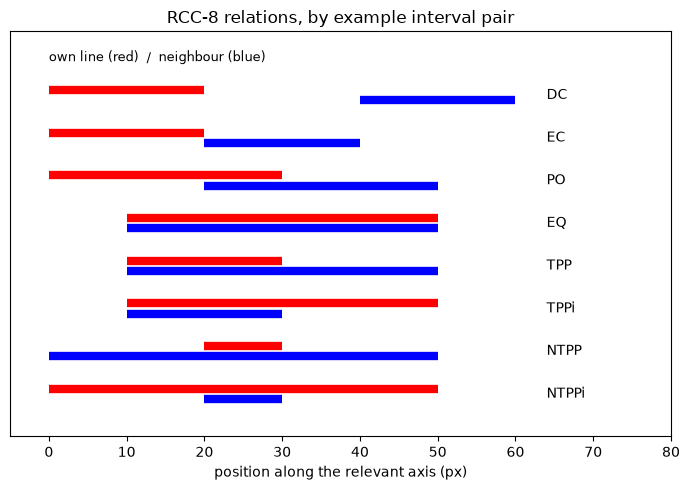

In [6]:
import matplotlib.pyplot as plt

from archival_structures.analysis import region_calculus

RELATION_EXAMPLES = [
    ('DC',    (0, 20),  (40, 60)),
    ('EC',    (0, 20),  (20, 40)),
    ('PO',    (0, 30),  (20, 50)),
    ('EQ',    (10, 50), (10, 50)),
    ('TPP',   (10, 30), (10, 50)),
    ('TPPi',  (10, 50), (10, 30)),
    ('NTPP',  (20, 30), (0, 50)),
    ('NTPPi', (0, 50),  (20, 30)),
]

fig, ax = plt.subplots(figsize=(7, 5))
for row, (label, (s1, e1), (s2, e2)) in enumerate(RELATION_EXAMPLES):
    computed = region_calculus.get_start_end_relation(None, None, start1=s1, start2=s2,
                                                       end1=e1, end2=e2, max_diff=0)
    assert computed == label, (label, computed)
    y = len(RELATION_EXAMPLES) - row
    ax.plot([s1, e1], [y + 0.12, y + 0.12], color='red', linewidth=6, solid_capstyle='butt')
    ax.plot([s2, e2], [y - 0.12, y - 0.12], color='blue', linewidth=6, solid_capstyle='butt')
    ax.text(64, y, label, va='center', fontsize=10)
ax.text(0, len(RELATION_EXAMPLES) + 0.8, 'own line (red)  /  neighbour (blue)', fontsize=9)
ax.set_xlim(-5, 80)
ax.set_ylim(0, len(RELATION_EXAMPLES) + 1.5)
ax.set_yticks([])
ax.set_xlabel('position along the relevant axis (px)')
ax.set_title('RCC-8 relations, by example interval pair')
plt.tight_layout()
plt.show()

## Most distinctive relational patterns per cluster

For a sample of non-noise relational clusters, the highest-mean-TF-IDF symbols -- the
`(own_line_cluster, direction, relation, neighbour_line_cluster)` triples that most distinguish
that cluster's pages from the rest of the corpus.

In [7]:
def top_distinctive_symbols(info, cluster_id, top_n=5):
    pattern = info['relational_pattern']
    member_ids = [scan_id for scan_id, c in info['rel_clusters'].items() if c == cluster_id]
    idxs = [pattern.id2idx[sid] for sid in member_ids if sid in pattern.id2idx]
    if not idxs:
        return []
    mean_vec = pattern.tfidf[idxs].mean(axis=0)
    top_idx = mean_vec.argsort()[::-1][:top_n]
    return [(pattern.vocab_inv[i], mean_vec[i]) for i in top_idx if mean_vec[i] > 0]


for inv_num, info in CORPORA.items():
    print(f"=== {inv_num} ({info['label']}) ===")
    cluster_ids = sorted(c for c in info['rel_clusters'].unique() if c != -1)
    for cluster_id in cluster_ids[:3]:
        n_members = (info['rel_clusters'] == cluster_id).sum()
        print(f"cluster {cluster_id} ({n_members} pages):")
        for (own, direction, relation, neighbour), weight in top_distinctive_symbols(info, cluster_id):
            print(f"    line-cluster {own} --{direction}:{relation}--> line-cluster {neighbour}"
                  f"  (tfidf={weight:.2f})")
    print()

=== NL-HaNA_2.10.50_1 (table register) ===
cluster 0 (21 pages):
    line-cluster 7 --right:DC--> line-cluster 16  (tfidf=4.93)
    line-cluster 7 --below:PO--> line-cluster 7  (tfidf=4.76)
    line-cluster 6 --right:DC--> line-cluster 27  (tfidf=3.95)
    line-cluster 27 --below:DC--> line-cluster 27  (tfidf=3.92)
    line-cluster 17 --below:PO--> line-cluster 17  (tfidf=3.41)
cluster 1 (50 pages):
    line-cluster 10 --below:PO--> line-cluster 10  (tfidf=2.27)
    line-cluster 29 --below:PO--> line-cluster 29  (tfidf=2.01)
    line-cluster 3 --below:PO--> line-cluster 3  (tfidf=1.99)
    line-cluster 3 --right:DC--> line-cluster 10  (tfidf=1.65)
    line-cluster 3 --right:DC--> line-cluster 29  (tfidf=1.61)
cluster 2 (53 pages):
    line-cluster 5 --below:PO--> line-cluster 5  (tfidf=2.25)
    line-cluster -1 --right:DC--> line-cluster 5  (tfidf=1.73)
    line-cluster 5 --below:PO--> line-cluster -1  (tfidf=1.42)
    line-cluster 20 --below:DC--> line-cluster 21  (tfidf=1.39)
    lin

### What do these patterns actually look like?

A `(line-cluster, direction, relation, line-cluster)` tuple isn't legible on its own -- it
doesn't say what those line-cluster ids actually look like, or what kind of text they contain.
For each top distinctive symbol printed above, find one real `(line, neighbour)` pair on an
actual page that produces that exact symbol, and crop the page thumbnail around both lines (own
line in red, neighbour in blue), with their transcribed text printed alongside.

In [8]:
from PIL import Image, ImageDraw
from IPython.display import display

from archival_structures.analysis.neighbourhood_analysis import LineNeighbourHood


def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def find_thumbnail(thumb_dir, scan_id):
    """Locate `scan_id`'s thumbnail regardless of naming convention (e.g. `<scan_id>` directly
    for NL-HaNA, `thumb-width_300-scan-<stem>.jp2.png` for NL-AsnDA) by matching on the scan's
    filename stem."""
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))


def page_thumbnail(page, info):
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(info['thumb_dir'], scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = info['scans_by_id'][scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def build_symbol_example_index(info):
    """For every relational symbol that occurs in `info['pages']`, the first `(page, line,
    neighbour)` triple that produces it -- a one-pass index for `show_symbol_example` below,
    mirroring what `RelationalPattern._compute_pattern_freq` itself does internally, so the
    relation/cluster labels are guaranteed consistent with the clustering above."""
    line_clusters = info['line_clusters']
    index = {}
    for page in info['pages']:
        lines = page.get_lines()
        if len(lines) < 2:
            continue
        neighbourhood = LineNeighbourHood(lines, max_vertical_dist=info['max_vertical_dist'])
        for line in lines:
            key = (page.id, line.id)
            own_cluster = line_clusters.loc[key] if key in line_clusters.index else -1
            for direction in ('below', 'right'):
                neighbours = neighbourhood.get_rel_neighbour(line, direction)
                if not neighbours:
                    continue
                neighbour = neighbours[0]
                relation = (region_calculus.get_vertical_region_relation(line, neighbour, max_diff=20)
                           if direction in ('above', 'below')
                           else region_calculus.get_horizontal_region_relation(line, neighbour, max_diff=20))
                n_key = (page.id, neighbour.id)
                neighbour_cluster = line_clusters.loc[n_key] if n_key in line_clusters.index else -1
                symbol = (own_cluster, direction, relation, neighbour_cluster)
                index.setdefault(symbol, (page, line, neighbour))
    return index


def show_symbol_example(info, symbol, margin=80):
    found = info['symbol_examples'].get(symbol)
    if found is None:
        print(f"  no example found for {symbol}")
        return None
    page, line, neighbour = found
    own, direction, relation, neighbour_cluster = symbol
    image = page_thumbnail(page, info).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    xs, ys = [], []
    for ln, color in ((line, 'red'), (neighbour, 'blue')):
        x, y = ln.coords.left * scale, ln.coords.top * scale
        w, h = ln.coords.width * scale, ln.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline=color, width=2)
        xs += [x, x + w]
        ys += [y, y + h]
    crop_box = (max(0, min(xs) - margin), max(0, min(ys) - margin),
                min(image.width, max(xs) + margin), min(image.height, max(ys) + margin))
    print(f"  page {page.id}: line-cluster {own} (red) --{direction}:{relation}--> "
          f"line-cluster {neighbour_cluster} (blue)")
    print(f"    own text:       {line.text!r}")
    print(f"    neighbour text: {neighbour.text!r}")
    return image.crop(crop_box)

=== NL-HaNA_2.10.50_1 (table register) ===
cluster 0:
  page NL-HaNA_2.10.50_1_0005.jpg: line-cluster 7 (red) --right:DC--> line-cluster 16 (blue)
    own text:       'Generaal en Chef'
    neighbour text: 'met L. Mo. Schip Amsterdam'


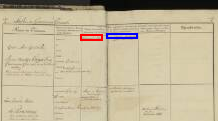

  page NL-HaNA_2.10.50_1_0005.jpg: line-cluster 7 (red) --below:PO--> line-cluster 7 (blue)
    own text:       '29 Januar 1815'
    neighbour text: 'Lrutent Kolonel'


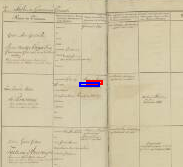

cluster 1:
  page NL-HaNA_2.10.50_1_0006.jpg-recto: line-cluster 10 (red) --below:PO--> line-cluster 10 (blue)
    own text:       'Gervol onslagen als resident'
    neighbour text: 'der preangee Regentschappen'


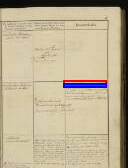

  page NL-HaNA_2.10.50_1_0006.jpg-recto: line-cluster 29 (red) --below:PO--> line-cluster 29 (blue)
    own text:       'Rocad dan Indies Aangesaeckt'
    neighbour text: 'ontslagen te depn als Kolonelo'


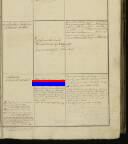

cluster 2:
  page NL-HaNA_2.10.50_1_0006.jpg-verso: line-cluster 5 (red) --below:PO--> line-cluster 5 (blue)
    own text:       'Luetent Kolle Adjist:'
    neighbour text: 'Beil: 2676er, 1215 42 45'


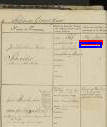

  page NL-HaNA_2.10.50_1_0006.jpg-verso: line-cluster -1 (red) --right:DC--> line-cluster 5 (blue)
    own text:       'vaoorsorg viick Brigins'
    neighbour text: 'Resl: 20 Julij 1215 452'


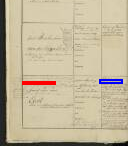

=== NL-AsnDA_0114.11_1 (notary deeds) ===
cluster 0:
  page NL-AsnDA_0114.11_1_0009.jpg-recto: line-cluster 19 (red) --right:DC--> line-cluster 26 (blue)
    own text:       'under'
    neighbour text: 'twintig cent'


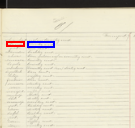

  page NL-AsnDA_0114.11_1_0009.jpg-recto: line-cluster 26 (red) --below:PO--> line-cluster 26 (blue)
    own text:       'twintig cent'
    neighbour text: 'tien cent'


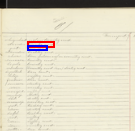

cluster 1:
  page NL-AsnDA_0114.11_1_0004.jpg-verso: line-cluster 17 (red) --right:DC--> line-cluster 14 (blue)
    own text:       '4test R Cuetoneel'
    neighbour text: 'De nummers vier, twee honderd zeven en negen'


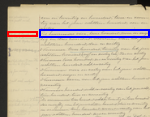

  page NL-AsnDA_0114.11_1_0004.jpg-verso: line-cluster 17 (red) --below:PO--> line-cluster 17 (blue)
    own text:       '4test R Cuetoneel'
    neighbour text: '299 tot h H Ennenge on'


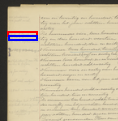

cluster 2:
  page NL-AsnDA_0114.11_1_0001.jpg: line-cluster -1 (red) --below:PO--> line-cluster 14 (blue)
    own text:       'De ondergeteekende Beederil On'
    neighbour text: 'ne Marie de Viemery mits ingang van heden'


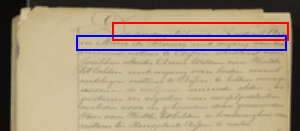

  page NL-AsnDA_0114.11_1_0001.jpg: line-cluster 14 (red) --below:PO--> line-cluster 14 (blue)
    own text:       'ne Marie de Viemery mits ingang van heden'
    neighbour text: 'benoemd notaris te Assen verwaart van'


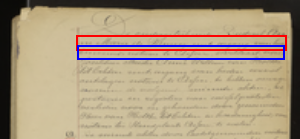

In [9]:
for inv_num, info in CORPORA.items():
    info['symbol_examples'] = build_symbol_example_index(info)
    print(f"=== {inv_num} ({info['label']}) ===")
    cluster_ids = sorted(c for c in info['rel_clusters'].unique() if c != -1)
    for cluster_id in cluster_ids[:3]:
        print(f"cluster {cluster_id}:")
        for symbol, weight in top_distinctive_symbols(info, cluster_id, top_n=2):
            display(show_symbol_example(info, symbol))
    print()

## Verso/recto symmetry: geometric vs. relational

Same sanity check as the other comparison notebooks: for every opening with both halves assigned
to a non-noise cluster, do verso and recto land in the *same* cluster? Run for both the
geometric and the relational clustering, side by side.

In [10]:
def same_cluster_pair_rate(clusters, pages):
    verso_ids = [page.id for page in pages if page.id.endswith('-verso')]
    matches, total = 0, 0
    for verso_id in verso_ids:
        recto_id = verso_id.replace('-verso', '-recto')
        if recto_id in clusters.index and clusters[verso_id] != -1 and clusters[recto_id] != -1:
            total += 1
            if clusters[verso_id] == clusters[recto_id]:
                matches += 1
    return matches, total


for inv_num, info in CORPORA.items():
    geo_matches, geo_total = same_cluster_pair_rate(info['geo_clusters'], info['pages'])
    rel_matches, rel_total = same_cluster_pair_rate(info['rel_clusters'], info['pages'])
    geo_rate = geo_matches / geo_total if geo_total else float('nan')
    rel_rate = rel_matches / rel_total if rel_total else float('nan')
    print(f"{inv_num} ({info['label']}):")
    print(f"  geometric:  {geo_matches}/{geo_total} ({geo_rate:.0%}) same-cluster verso/recto pairs")
    print(f"  relational: {rel_matches}/{rel_total} ({rel_rate:.0%}) same-cluster verso/recto pairs")

NL-HaNA_2.10.50_1 (table register):
  geometric:  0/0 (nan%) same-cluster verso/recto pairs
  relational: 0/48 (0%) same-cluster verso/recto pairs
NL-AsnDA_0114.11_1 (notary deeds):
  geometric:  22/23 (96%) same-cluster verso/recto pairs
  relational: 1/3 (33%) same-cluster verso/recto pairs


## Summary

Real, mixed results -- the relational fingerprint is genuinely complementary to the geometric
one, not a strict improvement:

- **`NL-HaNA_2.10.50_1` (table register):** the relational clustering finds far more structure
  than the geometric one (7% noise / 3 clusters vs. 81% noise / 2 clusters) -- exactly the case
  this fingerprint was meant to help with, where the pure pixel-pattern layout is too
  inconsistent across the corpus to cluster well. But its clusters don't track verso/recto
  symmetry (0/48 same-cluster pairs), matching the original hypothesis that this register's two
  halves of an opening can genuinely differ (e.g. row labels vs. data columns).
- **`NL-AsnDA_0114.11_1` (notary deeds):** here the geometric fingerprint already works very
  well (39% noise, 96% verso/recto symmetry), and the relational one does *worse* on both counts
  (65% noise, 33% symmetry on a small surviving sample of 3 pairs) -- the relational symbol
  vocabulary is much larger relative to corpus size here (320 symbols over 125 pages, built from
  a 27-cluster line-type vocabulary with 16% noise) than `GridPattern`'s pixel-pattern vocabulary
  (421 patterns over the same pages), so the resulting TF-IDF vectors are sparser and HDBSCAN
  finds less consistent structure in them at default settings. This isn't evidence the relational
  signal is uninformative for this corpus, just that it needs coarser line-type clustering and/or
  HDBSCAN tuning to compete with how well geometry alone already does here.
- **The distinctive symbols turn out to be legible, once you look at the actual lines behind
  them** (see "What do these patterns actually look like?" above) -- three recurring kinds of
  pattern show up:
  - **Row label vs. data column** (`right:DC`), exactly the table-register hypothesis from the
    verso/recto discussion: e.g. `'Generaal en Chef'` (cluster 7) sits `right:DC` of
    `'met L. Mo. Schip Amsterdam'` (cluster 16) -- two horizontally disconnected columns on the
    same row. The table register surfaces *several different* instances of this pattern as
    separate relational clusters (clusters 0 and 2 both contain a label/reference-column
    `right:DC` symbol, but with different line-cluster ids on each side), which the geometric
    fingerprint -- with no notion of column identity -- can't tell apart.
  - **Paragraph wrap** (`below:PO`, same line-cluster on both sides): e.g.
    `'Gervol onslagen als resident'` continuing into `'der preangee Regentschappen'`, or
    `'De ondergeteekende Beederil On'` into `'ne Marie de Viemery mits ingang van heden'` --
    consecutive lines of the same body-text type, vertically overlapping slightly, that are
    really one wrapped sentence. This is the pattern the original motivation (closing elements,
    paragraph continuation) was specifically after.
  - **Marginal annotation vs. body text** (`right:DC` / `below:PO` with different clusters on
    each side): in the notary deeds, `'4test R Cuetoneel'` (a short marginal note) sits next to
    and below `'De nummers vier, twee honderd zeven en negen'` -- a number-bearing body line --
    suggesting the relational fingerprint is picking up a marginalia/reference-number convention
    distinct from running prose, not just generic adjacency noise.

Net takeaway: the relational fingerprint earns its place as a *second* view, useful specifically
where geometry alone struggles (the table register), not as a replacement for it. The example
patterns above show the relational symbols are reading real structure (columns, paragraph wraps,
marginalia) rather than noise -- but the line-type vocabulary feeding it (currently a generic
HDBSCAN run) is itself a lever worth tuning before drawing firmer conclusions about which
patterns are most diagnostic of specific document elements.